# Expectation-Decider

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

## Reading CSV file to make Dataframe

In [41]:
Data = pd.read_csv("student_dataset.csv")
Data

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,13.1,41.5,Yes,45.6,Fail
1,13.9,93.5,Yes,59.5,Pass
2,5.2,70.3,Yes,43.9,Fail
3,11.4,53.2,Yes,86.7,Pass
4,16.3,81.9,Yes,40.9,Fail
...,...,...,...,...,...
495,3.6,52.4,Yes,34.2,Pass
496,6.3,72.3,Yes,79.3,Pass
497,6.1,91.5,No,77.6,Pass
498,19.3,87.1,No,99.5,Fail


In [42]:
Length = len(Data)
Length

500

### Student Analysis Report

In [43]:
Pass_Students = Data["final_exam_pass"].value_counts()
Pass_Students

final_exam_pass
Pass    320
Fail    180
Name: count, dtype: int64

In [44]:
Gd_Students = Data["group_discussion"].value_counts()
Gd_Students

group_discussion
Yes    298
No     202
Name: count, dtype: int64

### Task-1 : Understanding Basics

#### What is probability?

In [45]:
print("Probability is the measure of the likelihood that a particular event will occur.")
print("It quantifies uncertainly using a number between 0 and 1.")

Probability is the measure of the likelihood that a particular event will occur.
It quantifies uncertainly using a number between 0 and 1.


In [46]:
print("0 = Impossible Event")
print("0.5 = Equally likely to happen or not")
print("1 = Certain Event")

0 = Impossible Event
0.5 = Equally likely to happen or not
1 = Certain Event


#### Key Probability Terminology

In [47]:
print("Experiment : An action with certain results.")
print("Outcome : A possible result of an experiment.")
print("Event : One or  more outcomes we are traccking.")
print("Sample-Space : The set of all possible outcomes.")

Experiment : An action with certain results.
Outcome : A possible result of an experiment.
Event : One or  more outcomes we are traccking.
Sample-Space : The set of all possible outcomes.


#### Exapmles : 

In [48]:
Pass_count = (Data['final_exam_pass'] == 'Pass').sum()
Fail_count = (Data['final_exam_pass'] == 'Fail').sum()
Gd_yes     = (Data['group_discussion'] == 'Yes').sum()
High_att   = (Data['attendance'] > 80).sum()

print(f"  1) P(Student Passes Exam)         = {Pass_count}/{Length} = {Pass_count/Length:.4f}")
print(f"  2) P(Student in Group Discussion) = {Gd_yes}/{Length} = {Gd_yes/Length:.4f}")
print(f"  3) P(Attendance > 80%)            = {High_att}/{Length} = {High_att/Length:.4f}")

  1) P(Student Passes Exam)         = 320/500 = 0.6400
  2) P(Student in Group Discussion) = 298/500 = 0.5960
  3) P(Attendance > 80%)            = 158/500 = 0.3160


### Task-2 : Types of Events

#### Empirical Probability

In [49]:
print("Probability based on real-world data or actual observation from experiments or Dataests.")

Probability based on real-world data or actual observation from experiments or Dataests.


##### Example:

In [50]:
Prob_1 = Pass_count / Length
print(f"{Prob_1} = {Prob_1:.4f} = {Prob_1*100:.1f}")

0.64 = 0.6400 = 64.0


#### Theoritical Probability

In [51]:
print("Probability based on mathematical logic and assumption that all outcomes are equally likely.")
print("No data collection is required.")

Probability based on mathematical logic and assumption that all outcomes are equally likely.
No data collection is required.


##### Exapmle : 

In [52]:
Prob_2 = 0.5
print(f"{Prob_2} = 1/2 = {Prob_2:.4f} = 50%")

0.5 = 1/2 = 0.5000 = 50%


##### Diffenrences : 

In [53]:
print(f"Empirical : {Prob_1:.4f} ≠ Theoritical : {Prob_2:.4f} ")
print("More Students passed than expected technically.")
print("This shows studying & attandence improve real chances.")

Empirical : 0.6400 ≠ Theoritical : 0.5000 
More Students passed than expected technically.
This shows studying & attandence improve real chances.


### Task-3 Random Variable & Probability Distribution

In [54]:
print("A numerical quantity whose value depends on the outcomes of a random phenomenon.")
print("It acts as a container , turning real world events into number.")

A numerical quantity whose value depends on the outcomes of a random phenomenon.
It acts as a container , turning real world events into number.


In [55]:
print("X = Number of students who PASS out of 3 randomly selected.")
print("X can take values : 0,1,2,3")

X = Number of students who PASS out of 3 randomly selected.
X can take values : 0,1,2,3


#### Define : 

In [56]:
p = Pass_count / Length
q = 1 - p
n = 3

print(f"One student passes = {Pass_count}/{Length} = {p:.4f}")
print(f"One student fails = {Fail_count}/{Length} = {q:.4f}")

One student passes = 320/500 = 0.6400
One student fails = 180/500 = 0.3600


#### Mean,Variance & Std.Deviation

In [57]:
Mean_Rv = n*p
Variance_Rv = n*p*q
Standard_Deviation_Rv = Variance_Rv ** 0.5

print(f"Mean of Random-Variable = {Mean_Rv:.4f}")
print(f"Variance of Random-Variable = {Variance_Rv:.4f}")
print(f"Standard-Deviation of Random-Variable = {Standard_Deviation_Rv:.4f}")

Mean of Random-Variable = 1.9200
Variance of Random-Variable = 0.6912
Standard-Deviation of Random-Variable = 0.8314


#### Probability Distribution

##### Final-Exam-Pass

In [58]:

pmf = Data["final_exam_pass"].value_counts(normalize=True).sort_index()
print("Final Exam:")
pmf

Final Exam:


final_exam_pass
Fail    0.36
Pass    0.64
Name: proportion, dtype: float64

##### Group-Discussion

In [59]:
pmf_gd = Data["group_discussion"].value_counts(normalize=True).sort_index()
print("Group Discussion:")
pmf_gd

Group Discussion:


group_discussion
No     0.404
Yes    0.596
Name: proportion, dtype: float64

##### Study-Hours

In [60]:
pmf_study = Data["study_hours"].value_counts(normalize=True).sort_index()
print("Study Hours:")
pmf_study

Study Hours:


study_hours
1.1     0.004
1.2     0.004
1.3     0.002
1.4     0.002
1.5     0.006
        ...  
19.5    0.008
19.6    0.008
19.8    0.006
19.9    0.010
20.0    0.006
Name: proportion, Length: 178, dtype: float64

##### previous-test-score

In [61]:
pmf_score = Data["previous_test_score"].value_counts(normalize=True).sort_index()
print("Previous Test Score:")
pmf_score

Previous Test Score:


previous_test_score
30.1     0.002
30.4     0.002
30.5     0.002
30.7     0.004
31.1     0.002
         ...  
98.5     0.002
99.2     0.002
99.5     0.004
99.9     0.004
100.0    0.002
Name: proportion, Length: 361, dtype: float64

##### Attendance

In [62]:
pmf_att = Data["attendance"].value_counts(normalize=True).sort_index()
print("Attendance:")
pmf_att

Attendance:


attendance
40.2     0.004
40.3     0.004
40.4     0.002
40.6     0.004
40.8     0.002
         ...  
99.5     0.002
99.6     0.004
99.8     0.002
99.9     0.002
100.0    0.002
Name: proportion, Length: 339, dtype: float64

### Task-4 Venn diagram in probability

In [63]:
Study_Set = Data["study_hours"]>10
Attend_Set = Data["attendance"]>80

A = len(Data[Study_Set])
B = len(Data[Attend_Set])
A_and_B = len(Data[Study_Set & Attend_Set])
Only_A = A - A_and_B
Only_B = B - A_and_B
Neither = Length-(Only_A + Only_B + A_and_B)
A_or_B = A + B - A_and_B

print(f"Set-A : Studnets who study more than 10hrs/wk = {A} students.")
print(f"Set-B : Students with attendance above 80% = {B} students.")
print(f"Both conditions A ∩ B : {A_and_B} students.")
print(f"Only A(not B) : {Only_A} students.")
print(f"Only B(not A) : {Only_B} students.")
print(f"Neither condition : {Neither} students.")
print()

print(f"P(A) = {A}/{Length} = {A/Length:.4f}")
print(f"P(B) = {B}/{Length} = {B/Length:.4f}")
print(f"P(A ∩ B) = {A_and_B}/{Length} = {A_and_B / Length:.4f}")
print(f"P(A U B) = P(A)+P(B) - p(A ∩ B) = {A_or_B}/{Length} = {A_or_B / Length:.4f}")

Set-A : Studnets who study more than 10hrs/wk = 284 students.
Set-B : Students with attendance above 80% = 158 students.
Both conditions A ∩ B : 83 students.
Only A(not B) : 201 students.
Only B(not A) : 75 students.
Neither condition : 141 students.

P(A) = 284/500 = 0.5680
P(B) = 158/500 = 0.3160
P(A ∩ B) = 83/500 = 0.1660
P(A U B) = P(A)+P(B) - p(A ∩ B) = 359/500 = 0.7180


#### Venn Diagram

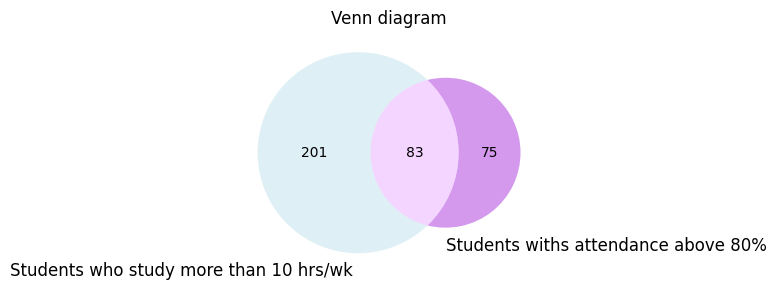

In [64]:
from matplotlib_venn import venn2

plt.figure()
venn2(
    subsets=(Only_A,Only_B,A_and_B),
    set_labels=("Students who study more than 10 hrs/wk ","Students withs attendance above 80%"),
    set_colors=("lightblue","darkviolet")
)
plt.tight_layout()
plt.title("Venn diagram")
plt.show()

### Task-5 : Contingency Table & Probability calculation

#### Coningency-Table

In [65]:
contingency_table = pd.crosstab(Data["group_discussion"], Data["final_exam_pass"], margins=True)
contingency_table

final_exam_pass,Fail,Pass,All
group_discussion,,,
No,78,124,202
Yes,102,196,298
All,180,320,500


#### Joint Probability

In [66]:
joint_probability_table = contingency_table / contingency_table.values.sum()
joint_probability_table

final_exam_pass,Fail,Pass,All
group_discussion,,,
No,0.039,0.062,0.101
Yes,0.051,0.098,0.149
All,0.090,0.160,0.250


#### Marginal Probability

In [67]:
row_marginal = contingency_table.sum(axis=1) / contingency_table.values.sum()
row_marginal

group_discussion
No     0.202
Yes    0.298
All    0.500
dtype: float64

In [68]:
column_marginal = contingency_table.sum(axis=0) / contingency_table.values.sum()
column_marginal

final_exam_pass
Fail    0.18
Pass    0.32
All     0.50
dtype: float64

#### Conditional Probability

In [69]:
conditional_row = contingency_table.div(contingency_table.sum(axis=1), axis=0)
conditional_row

final_exam_pass,Fail,Pass,All
group_discussion,,,
No,0.193069,0.306931,0.5
Yes,0.171141,0.328859,0.5
All,0.180000,0.320000,0.5


In [70]:
conditional_col = contingency_table.div(contingency_table.sum(axis=0), axis=1)
conditional_col

final_exam_pass,Fail,Pass,All
group_discussion,,,
No,0.216667,0.19375,0.202
Yes,0.283333,0.30625,0.298
All,0.500000,0.50000,0.500


### Task-6 : Understanding Relationships

#### Interpret conditional probability results in plain language ("Intution" behind the formula)

In [ ]:
conditional_probability_table = joint_probability_table.div(row_marginal, axis=0)
conditional_probability_table

p_pass_given_yes = conditional_probability_table.loc["Yes", "Pass"]
p_pass_given_no  = conditional_probability_table.loc["No",  "Pass"]
p_pass_overall   = row_marginal = contingency_table.sum(axis=0) / contingency_table.values.sum()
p_pass_overall   = p_pass_overall.loc["Pass"]

print("Conditional Probability Interpretation")
print()
print(f"P(Pass | GD = Yes) = {p_pass_given_yes:.4f} = {p_pass_given_yes*100:.2f}%")
print(f"P(Pass | GD = No)  = {p_pass_given_no:.4f} = {p_pass_given_no*100:.2f}%")
print(f"P(Pass overall) = {p_pass_overall:.4f} = {p_pass_overall*100:.2f}%")

Conditional Probability Interpretation

  P(Pass | GD = Yes) = 0.3289 = 32.89%
  P(Pass | GD = No)  = 0.3069 = 30.69%
  P(Pass overall)    = 0.3200 = 32.00%


In [72]:
total = contingency_table.values.sum()          
gd_yes_total = contingency_table.loc["Yes"].sum()      
gd_yes_pass  = contingency_table.loc["Yes", "Pass"]    

print("INTUITION — P(Pass | GD = Yes)")
print()
print(f"Total students = {total}")
print(f"Students who joined GD = {gd_yes_total}")
print(f"Among those, who passed = {gd_yes_pass}")
print()
print(f"Out of {gd_yes_total} students who joined GD,")
print(f"{gd_yes_pass} of them passed.")
print()
print(f"So P(Pass | GD=Yes) = {gd_yes_pass} / {gd_yes_total} = {gd_yes_pass/gd_yes_total:.4f}")

INTUITION — P(Pass | GD = Yes)

Total students = 2000
Students who joined GD = 596
Among those, who passed = 196

Out of 596 students who joined GD,
196 of them passed.

So P(Pass | GD=Yes) = 196 / 596 = 0.3289


#### Identify "participating in group discussions" and "passing exam" are independent , dependent , or mutually exclusive events. Justify your answer.

In [77]:

contingency_table = pd.crosstab(Data["group_discussion"], Data["final_exam_pass"])

total = contingency_table.values.sum()          
gd_yes_pass = contingency_table.loc["Yes", "Pass"] 
gd_yes_total = contingency_table.loc["Yes"].sum()  
pass_total = contingency_table["Pass"].sum()       

p_gd_yes      = gd_yes_total / total      
p_pass        = pass_total   / total      
p_gd_and_pass = gd_yes_pass  / total      

print("Independent Event : Occurrence of one event does not affect the other")
print(f"P(GD = Yes) = {gd_yes_total}/{total} = {p_gd_yes:.4f}")
print()
print("Dependent Event : Occurrence of one event affects the other.")
print(f"P(Pass) = {pass_total}/{total} = {p_pass:.4f}")
print()
print("Two events cannot happen together.")
print(f"P(GD=Yes AND Pass) = {gd_yes_pass}/{total} = {p_gd_and_pass:.4f}")

Independent Event : Occurrence of one event does not affect the other
P(GD = Yes) = 298/500 = 0.5960

Dependent Event : Occurrence of one event affects the other.
P(Pass) = 320/500 = 0.6400

Two events cannot happen together.
P(GD=Yes AND Pass) = 196/500 = 0.3920


In [80]:
total = 500
pass_students     = 320
fail_students     = 180
high_att_students = 300   


P_pass = pass_students / total   
P_fail = fail_students / total   
P_high_att = 0.60                    
P_high_att_pass = 0.70                    
P_high_att_fail = 0.40                    

P_pass_given_high_att = (P_high_att_pass * P_pass) / P_high_att

print(f"Students pass at high attendance = {pass_students}.")
print(f"Students fail at high attendance = {fail_students}.")
print(f"High attendance students had high attendance = {high_att_students}.")
P_pass_given_high_att

Students pass at high attendance = 320.
Students fail at high attendance = 180.
High attendance students had high attendance = 300.


0.7466666666666666